In [1]:
from pathlib import Path

In [2]:
path = Path("./../dl/1/HousingData.csv")

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(path)

In [5]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [6]:
df.isna().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [7]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.200000,4.0900,1,296,15.3,396.90,4.980000,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.900000,4.9671,2,242,17.8,396.90,9.140000,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.100000,4.9671,2,242,17.8,392.83,4.030000,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.800000,6.0622,3,222,18.7,394.63,2.940000,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.200000,6.0622,3,222,18.7,396.90,12.715432,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.100000,2.4786,1,273,21.0,391.99,12.715432,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.700000,2.2875,1,273,21.0,396.90,9.080000,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.000000,2.1675,1,273,21.0,396.90,5.640000,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.300000,2.3889,1,273,21.0,393.45,6.480000,22.0


In [8]:
df.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [9]:
x = df.drop("MEDV", axis=1)

In [10]:
y = df.MEDV

In [11]:
x.shape

(506, 13)

In [12]:
y.shape

(506,)

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [15]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

In [16]:
model = Sequential([
    layers.Input(shape=(x_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

In [17]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanSquaredError,
        tf.keras.metrics.MeanAbsoluteError
    ]
)

In [18]:
history = model.fit(
    x_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
)    

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 607.1395 - mean_absolute_error: 22.7440 - mean_squared_error: 607.1395 - val_loss: 523.8653 - val_mean_absolute_error: 21.3399 - val_mean_squared_error: 523.8653
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 552.4042 - mean_absolute_error: 21.5127 - mean_squared_error: 552.4042 - val_loss: 464.1308 - val_mean_absolute_error: 19.9217 - val_mean_squared_error: 464.1308
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 471.4983 - mean_absolute_error: 19.5898 - mean_squared_error: 471.4983 - val_loss: 363.2556 - val_mean_absolute_error: 17.3210 - val_mean_squared_error: 363.2556
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 341.3809 - mean_absolute_error: 16.1269 - mean_squared_error: 341.3809 - val_loss: 224.7849 - val_mean_absolute_error: 13.0996 - val_mean_squared_error: 224.7849
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 193.2239 - mean_absolute_error: 11.3047 - mean_squared_e

In [19]:
from sklearn.metrics import classification_report, mean_absolute_error, mean_squared_error

In [20]:
y_pred = model.predict(x_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [21]:
y_pred.shape

(102, 1)

In [22]:
y_test.shape

(102,)

In [23]:
y_pred = y_pred.flatten()
y_pred.shape

(102,)

In [24]:
print(mean_absolute_error(y_test, y_pred))

2.317354060154335


In [25]:
print(mean_squared_error(y_test, y_pred))

13.243795006876386


In [26]:
import matplotlib.pyplot as plt

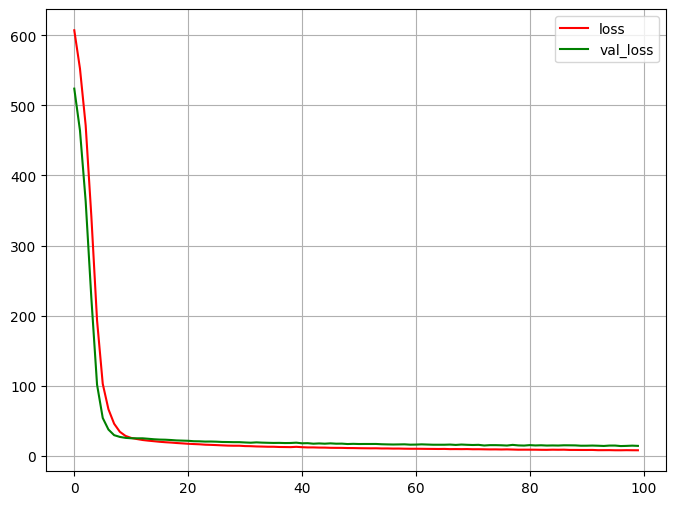

In [27]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label="loss", color="red")
plt.plot(history.history['val_loss'], label="val_loss", color="green")
plt.legend()
plt.grid()
plt.show()

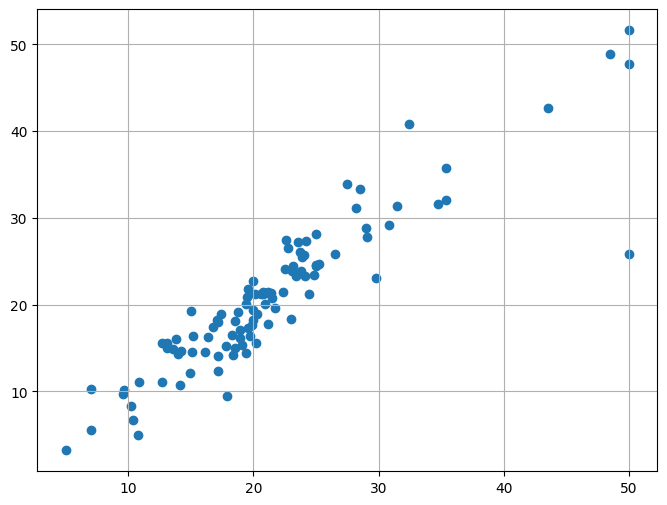

In [31]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.grid()
plt.show()

In [28]:
import inspect
print(inspect.getsource(model.fit))

    @traceback_utils.filter_traceback
    def fit(
        self,
        x=None,
        y=None,
        batch_size=None,
        epochs=1,
        verbose="auto",
        callbacks=None,
        validation_split=0.0,
        validation_data=None,
        shuffle=True,
        class_weight=None,
        sample_weight=None,
        initial_epoch=0,
        steps_per_epoch=None,
        validation_steps=None,
        validation_batch_size=None,
        validation_freq=1,
    ):
        self._assert_compile_called("fit")
        # Possibly cap epochs for debugging runs.
        max_epochs = config.max_epochs()
        if max_epochs and max_epochs < epochs:
            warnings.warn("Limiting epochs to %d" % max_epochs)
            epochs = max_epochs
        # TODO: respect compiled trainable state
        self._eval_epoch_iterator = None
        if validation_split and validation_data is None:
            # Create the validation data using the training data. Only supported
            # 